In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import (load_czi_file)
from napari import viewer
from skimage import filters
from image_processing import create_binary_mask, watershed_segmentation
from skimage.morphology import disk, rectangle, closing, opening, erosion, dilation
from skimage.measure import label
from circularity import circ_filter
from scipy import ndimage as ndi
from circle_fitting import complete_circle_fitting_workflow as circle_fitting
from scipy.ndimage import binary_fill_holes
from skimage.segmentation import watershed


In [2]:
view = viewer.Viewer()

In [3]:
path = '/Users/taskina/Desktop/confocal/3KLMut_4KLWT_mixing_WOD/2025_08_04/4August2025_evening/Snap-5081.czi'

In [4]:
def process_image(path):

    gaus_size=4
    closing_size=2
    ws_size=4

    I = load_czi_file(path, channel=0)
    #view.add_image(I)
    I_filtered = filters.gaussian(I, sigma=gaus_size)
    #view.add_image(I_filtered)
    I_bin, tr = create_binary_mask(I_filtered, method='threshold_li')
    #view.add_image(I_bin)
    I_closed = ~closing(~I_bin, disk(closing_size))
    #view.add_image(I_closed)
    labels = label(I_closed, connectivity=1)
    #view.add_labels(labels)
    labels_ws = watershed_segmentation(labels, disk_size=ws_size, min_distance=12)
    #view.add_labels(labels_ws)
    lbls_filtered = circ_filter(labels_ws, circularity_filter='none', size_filter='yen')[0]
    #view.add_labels(lbls_filtered)
    circles, metrics = circle_fitting(lbls_filtered, image=I, method='contour')
    return lbls_filtered, metrics

Fitted 26 circles using 'contour' method
Mean radial error: 16.04 pixels
Mean coverage: 98.7%
Mean circularity: 0.998


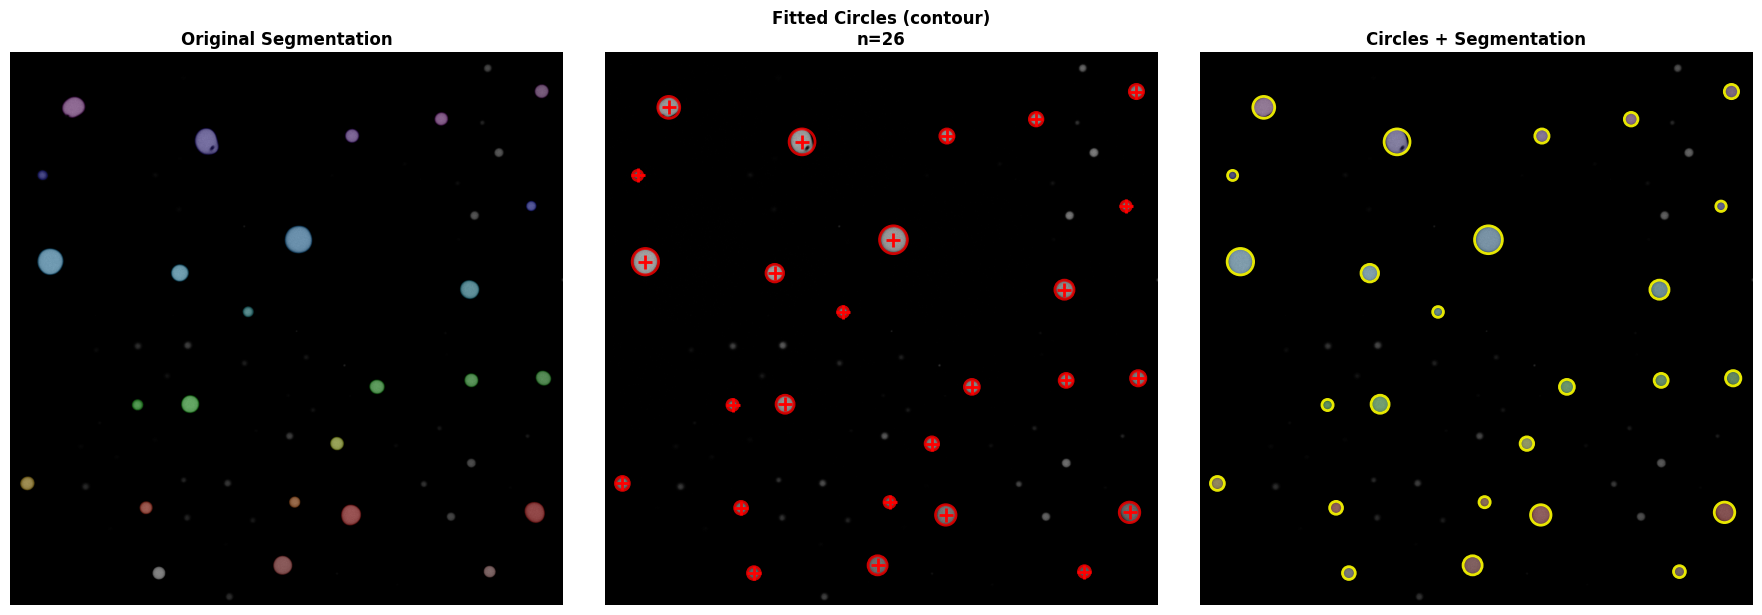

In [5]:
condensates, metrics_conds = process_image(path)

In [6]:
I = load_czi_file(path, channel=0)
view.add_image(I)

<Image layer 'I' at 0x335ec5e80>

In [7]:
I_wod = load_czi_file(path, channel=1)
view.add_image(I_wod)

<Image layer 'I_wod' at 0x10f5b5590>

In [8]:
I_filtered = filters.median(I_wod, disk(16))
view.add_image(I_filtered)

<Image layer 'I_filtered' at 0x33b3356d0>

In [9]:
view.add_labels(condensates)

<Labels layer 'condensates' at 0x335986cf0>

In [10]:
I_bin, tr = create_binary_mask(I_filtered, threshold=25)

In [11]:
view.add_image(I_bin)

<Image layer 'I_bin' at 0x10f69f890>

In [12]:
I_closed = ~closing(~I_bin, disk(60))

In [13]:
view.add_image(I_closed)

<Image layer 'I_closed' at 0x36f795bd0>

In [14]:
I_filled = binary_fill_holes(I_closed)

In [15]:
view.add_labels(I_filled)

<Labels layer 'I_filled' at 0x335818550>

In [16]:
distance = ndi.distance_transform_edt(I_filled)

In [17]:
labels = label(I_filled, connectivity=1)
view.add_labels(labels)

<Labels layer 'labels' at 0x36f97e490>

In [18]:
view.add_image(distance)

<Image layer 'distance' at 0x3769e11d0>

In [19]:
coords = np.array([[int(v['center'][0]), int(v['center'][1])] for v in metrics_conds.values()])

In [20]:
view.add_points(coords)

<Points layer 'coords' at 0x335985fd0>

In [21]:
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

In [22]:
labels_ws = watershed(-distance, markers, mask=labels)

In [23]:
view.add_labels(labels_ws)

<Labels layer 'labels_ws' at 0x10f69f9d0>

Fitted 24 circles using 'contour' method
Mean radial error: 85.78 pixels
Mean coverage: 95.3%
Mean circularity: 0.920


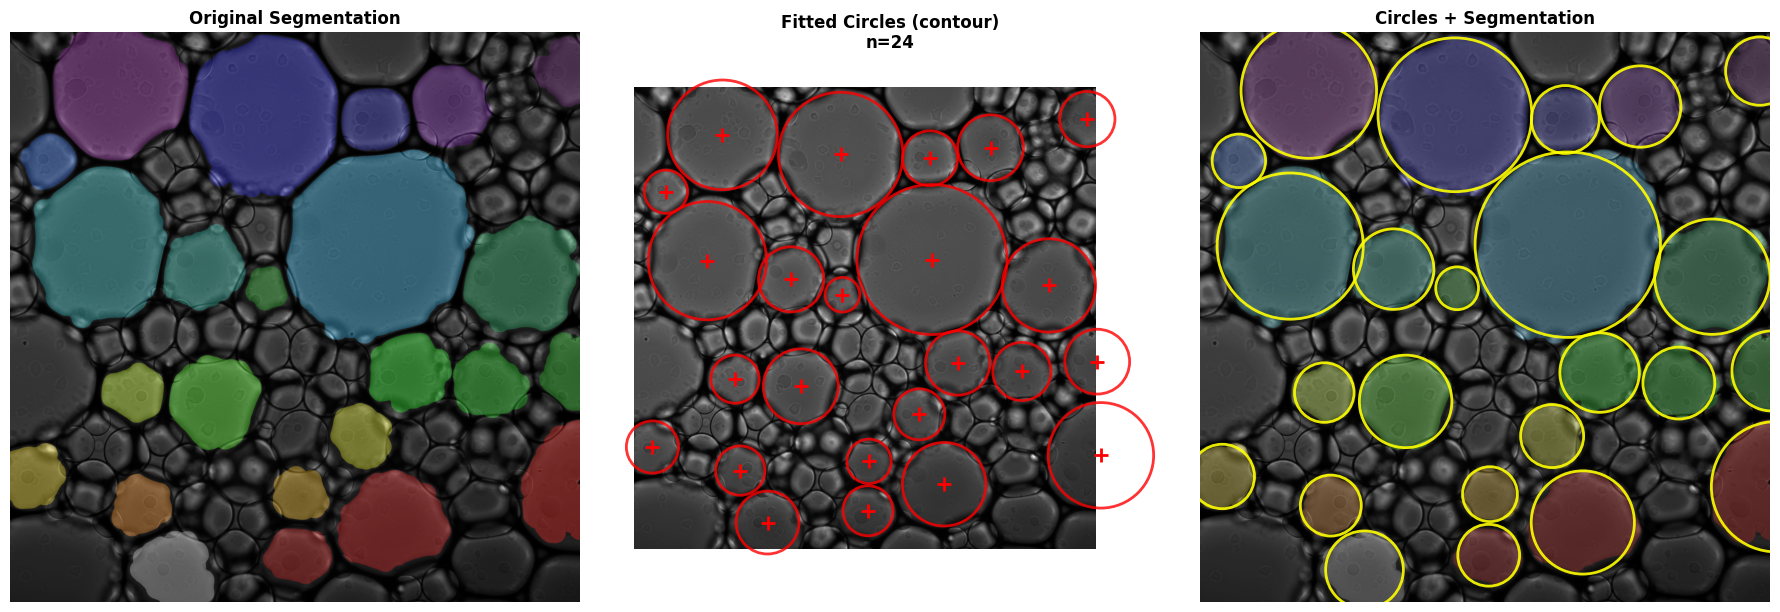

In [24]:
circles, metrics_wod = circle_fitting(labels_ws, image=I_wod, method='contour')

In [25]:
from circle_fitting import complete_paired_analysis, analyze_paired_volumes

Fitting circles to condensates...
Fitted 26 circles using 'area' method
Mean radial error: 15.99 pixels
Mean coverage: 98.6%
Mean circularity: 1.000

Fitting circles to water-in-oil droplets...
Fitted 24 circles using 'area' method
Mean radial error: 81.40 pixels
Mean coverage: 92.5%
Mean circularity: 1.000

Pairing condensates with containing droplets...

Condensate-Droplet Pairing Summary
Total condensates: 26
Paired condensates: 24
Unpaired condensates: 2
Pairing rate: 92.3%

────────────────────────────────────────────────────────────
Volume Analysis (µm²)
────────────────────────────────────────────────────────────

Condensate volumes:
  Mean ± Std: 315.74 ± 194.49
  Range: [106.99, 810.87]

WOD volumes:
  Mean ± Std: 8381.87 ± 7911.45
  Range: [1747.06, 34705.93]

Volume ratios (Condensate/WOD):
  Mean ± Std: 0.0108 ± 0.0069
  Range: [0.0036, 0.0337]

Radius ratios (Condensate/WOD):
  Mean ± Std: 0.2131 ± 0.0405
  Range: [0.1529, 0.3230]


Generating visualizations...


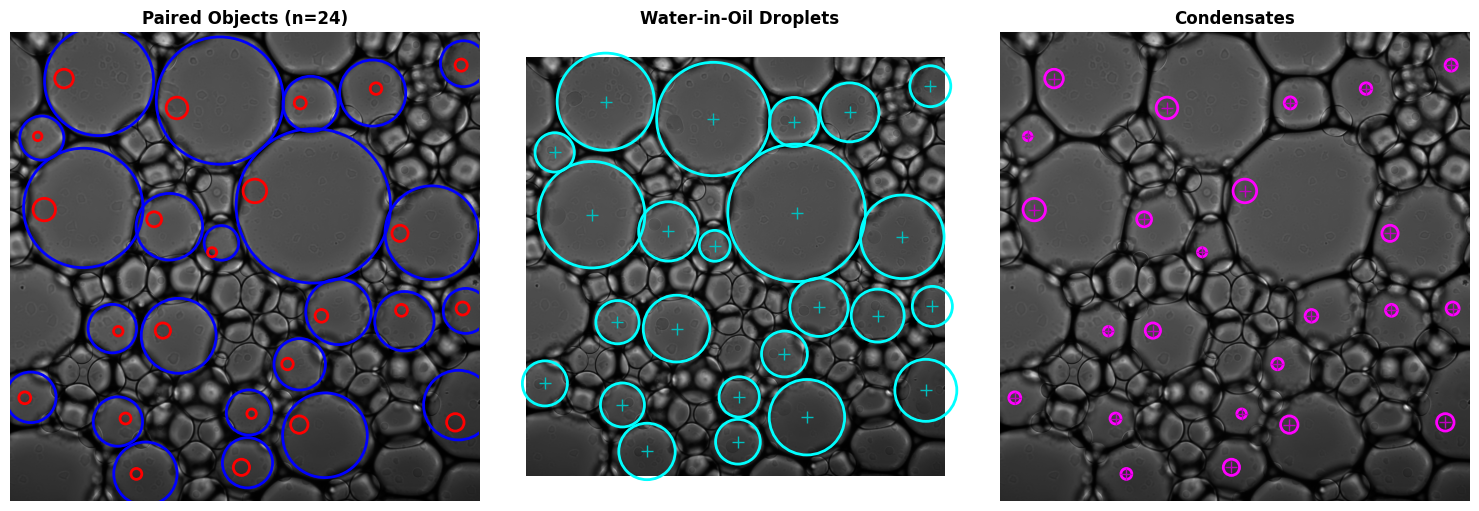

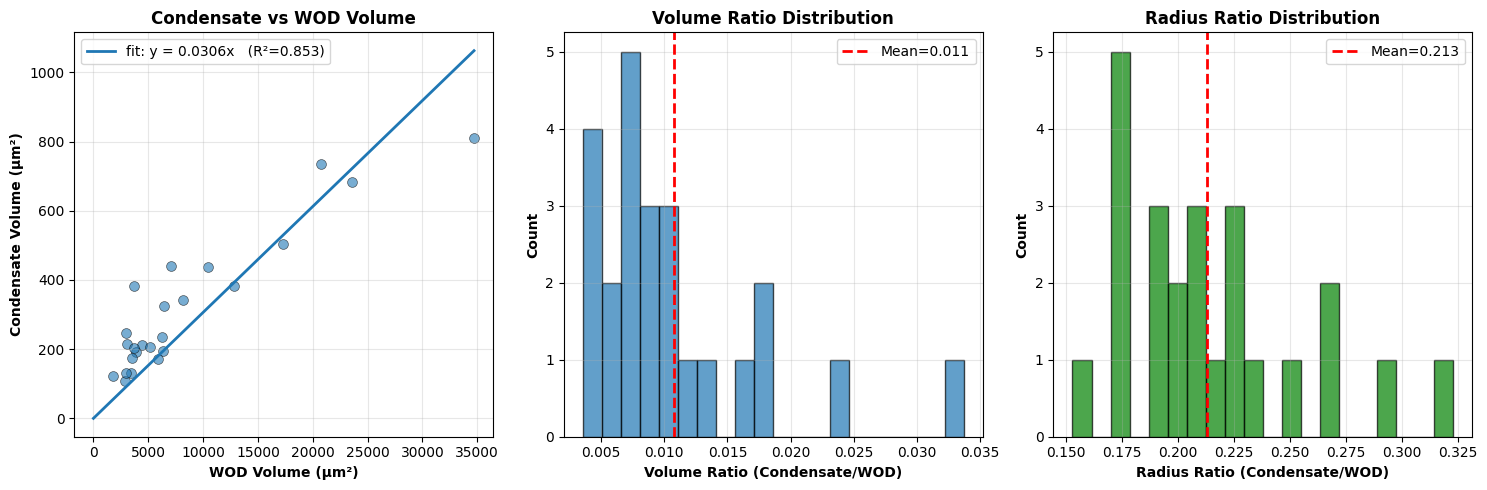

In [26]:
pairs, results = complete_paired_analysis(condensates, labels_ws, I_wod, pixel_size={'x_um':0.1952, 'y_um':0.1952}, is_2d=True)

In [148]:
metrics

[{'label': np.int32(2),
  'center': (np.float64(231.9480291909932), np.float64(3146.5346157994736)),
  'radius': np.float64(42.23252746621236),
  'coverage': np.float64(0.9907192575406032),
  'mean_error': np.float64(14.07852205611857),
  'area': np.int64(5603),
  'circle_area': np.float64(5603.301856463694)},
 {'label': np.int32(3),
  'center': (np.float64(325.73483859686695), np.float64(377.1443824148962)),
  'radius': np.float64(64.8055869870969),
  'coverage': np.float64(0.9534408357937769),
  'mean_error': np.float64(21.58696290292707),
  'area': np.int64(13209),
  'circle_area': np.float64(13193.948058268157)},
 {'label': np.int32(4),
  'center': (np.float64(395.7014938509428), np.float64(2552.5401491155335)),
  'radius': np.float64(40.231953248512035),
  'coverage': np.float64(0.9885916601101495),
  'mean_error': np.float64(13.41340082214165),
  'area': np.int64(5084),
  'circle_area': np.float64(5085.013480404062)},
 {'label': np.int32(6),
  'center': (np.float64(495.6512683520